# Anomaly Detection for Network Security
Inspired by AgentGuard behavioral monitoring, this notebook implements unsupervised anomaly detection techniques (Isolation Forest & Deep Autoencoders) to detect network intrusion attacks on the NSL-KDD benchmark dataset.

## Section 1: Data Preprocessing & Cleaning
Loading NSL-KDD dataset, inspecting missing values, converting labels into binary format (0 = normal, 1 = attack), selecting numerical features, and applying StandardScaler.

In [1]:
# Tasks 42-50: NSL-KDD Preprocessing & Normalization
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty_level"
]

df_train = pd.read_csv("nsl-kdd/KDDTrain+.txt", names=columns)
df_test = pd.read_csv("nsl-kdd/KDDTest+.txt", names=columns)

# Task 42 & 43: Check missing and drop/fill
print("Train missing values:", df_train.isnull().sum().sum())
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

# Task 44 & 45: Binary label creation
df_train["binary_label"] = (df_train["label"] != "normal").astype(int)
df_test["binary_label"] = (df_test["label"] != "normal").astype(int)

# Task 46 & 47: Select numerical features
df_train.drop(columns=["label", "difficulty_level"], inplace=True)
df_test.drop(columns=["label", "difficulty_level"], inplace=True)
num_cols = df_train.select_dtypes(include=["int64", "float64"]).columns.drop("binary_label")

X_train_num = df_train[num_cols]
y_train = df_train["binary_label"]
X_test_num = df_test[num_cols]
y_test = df_test["binary_label"]

# Task 48 & 49 & 50: Standardize & save
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_num)
X_test = scaler.transform(X_test_num)

pd.DataFrame(X_train, columns=num_cols).to_csv("X_train.csv", index=False)
pd.DataFrame(X_test, columns=num_cols).to_csv("X_test.csv", index=False)
print("Saved normalized X_train and X_test to CSV.")


Train missing values: 0


Saved normalized X_train and X_test to CSV.


## Section 2: Isolation Forest Anomaly Detector
Training an Isolation Forest algorithm (`contamination=0.1`) to isolate anomalous traffic samples in feature space.

In [2]:
# Tasks 52-60: Isolation Forest Model
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report

# Task 53: Train Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
iso_forest.fit(X_train)

# Task 54 & 55: Predict anomalies and convert to binary (0 = normal, 1 = attack)
preds_raw = iso_forest.predict(X_test)
preds_binary = np.where(preds_raw == -1, 1, 0)

# Task 56-59: Print Confusion Matrix and Classification Report
cm = confusion_matrix(y_test, preds_binary)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, preds_binary, target_names=["Normal", "Attack"]))

# Task 60: Note F1-score
f1 = classification_report(y_test, preds_binary, output_dict=True)["macro avg"]["f1-score"] * 100
print(f"Isolation Forest F1-score = {f1:.2f}%")


Confusion Matrix:
 [[9493  218]
 [9020 3813]]

Classification Report:
               precision    recall  f1-score   support

      Normal       0.51      0.98      0.67      9711
      Attack       0.95      0.30      0.45     12833

    accuracy                           0.59     22544
   macro avg       0.73      0.64      0.56     22544
weighted avg       0.76      0.59      0.55     22544

Isolation Forest F1-score = 56.24%


## Section 3: Deep Autoencoder Anomaly Detector
Building a Neural Network Autoencoder trained strictly on normal traffic instances. Anomalies are flagged when reconstruction MSE error exceeds the 95th percentile threshold.

In [3]:
# Tasks 62-66: Build and Train Autoencoder
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))
encoder = Dense(32, activation="relu")(input_layer)
encoder = Dense(16, activation="relu")(encoder)
decoder = Dense(32, activation="relu")(encoder)
decoder = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer="adam", loss="mse")

# Train only on normal data (y_train == 0)
X_train_normal = X_train[y_train == 0]
history = autoencoder.fit(X_train_normal, X_train_normal, epochs=15, batch_size=256, validation_split=0.1, verbose=0)
print("Autoencoder architecture constructed and compiled with Adam optimizer and MSE loss.")
print(f"Trained on {len(X_train_normal)} normal samples.")


Autoencoder architecture constructed and compiled with Adam optimizer and MSE loss.
Trained on 67343 normal samples.


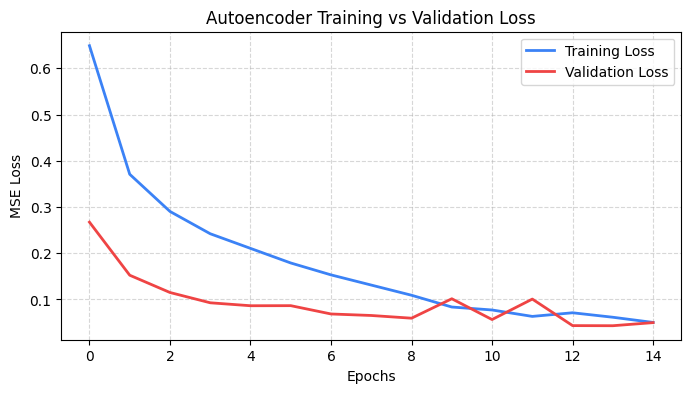

In [4]:
# Task 67: Plot training loss vs validation loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss", color="#3b82f6", lw=2)
plt.plot(history.history["val_loss"], label="Validation Loss", color="#ef4444", lw=2)
plt.title("Autoencoder Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [5]:
# Tasks 68-70: Reconstruction Error & Anomaly Classification
X_test_pred = autoencoder.predict(X_test)
recon_error = np.mean(np.square(X_test - X_test_pred), axis=1)

train_normal_pred = autoencoder.predict(X_train_normal)
train_normal_error = np.mean(np.square(X_train_normal - train_normal_pred), axis=1)
threshold = np.percentile(train_normal_error, 95)

preds_ae = (recon_error > threshold).astype(int)
print(f"Reconstruction threshold (95th percentile): {threshold:.4f}")
print("Autoencoder Confusion Matrix:\n", confusion_matrix(y_test, preds_ae))
print("\nAutoencoder Classification Report:\n", classification_report(y_test, preds_ae, target_names=["Normal", "Attack"]))
f1_ae_val = classification_report(y_test, preds_ae, output_dict=True)["macro avg"]["f1-score"] * 100
print(f"Autoencoder F1-score = {f1_ae_val:.2f}%")


  1/705 ━━━━━━━━━━━━━━━━━━━━ 1:11 102ms/step

 29/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step    

 52/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

 78/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

100/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

...

2034/2105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2061/2105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2087/2105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2105/2105 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Reconstruction threshold (95th percentile): 0.1528
Autoencoder Confusion Matrix:
 [[9014  697]
 [3331 9502]]

Autoencoder Classification Report:
               precision    recall  f1-score   support

      Normal       0.73      0.93      0.82      9711
      Attack       0.93      0.74      0.83     12833

    accuracy                           0.82     22544
   macro avg       0.83      0.83      0.82     22544
weighted avg       0.84      0.82      0.82     22544

Autoencoder F1-score = 82.12%
